# Clasificación multiclase

## Introduction

En este ejercicio se implementa la regresion one-vs-all
Antes de empezar la ejecución de las partes de codigo correspondienters a los ejercicios, se requiere importar todas las librerias necesarias.

In [11]:
# Importa la herramienta de Google Colab para poder conectar Google Drive
from google.colab import drive

# Conecta (monta) Google Drive en la carpeta /content/drive para acceder a archivos del Drive
drive.mount('/content/drive')

# Imprime un mensaje para confirmar que la conexión se realizó
print("Drive conectado correctamente.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive conectado correctamente.


In [12]:
# Librerías básicas

# Importa NumPy para trabajar con matrices, vectores y cálculos numéricos
import numpy as np

# Importa Pandas para cargar y manipular datos en formato de tablas (CSV, DataFrames)
import pandas as pd

# Importa Matplotlib para crear gráficos y visualizar datos o imágenes
import matplotlib.pyplot as plt


# PyTorch

# Importa PyTorch, la librería principal para crear y entrenar redes neuronales
import torch

# Importa el módulo de redes neuronales de PyTorch (capas, funciones de activación, etc.)
import torch.nn as nn

# Importa optimizadores de PyTorch (algoritmos que ajustan los pesos del modelo)
import torch.optim as optim


# Dataset y DataLoader

# Dataset permite crear datasets personalizados para PyTorch
# DataLoader permite cargar los datos en batches durante el entrenamiento
from torch.utils.data import Dataset, DataLoader


# Mensaje para confirmar que todas las librerías se cargaron correctamente
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [13]:
# 3. CONFIGURAR DISPOSITIVO (CPU / GPU)

# Verifica si hay una GPU disponible (CUDA).
# Si existe usa "cuda" para entrenar más rápido, si no usa "cpu".
device = "cuda" if torch.cuda.is_available() else "cpu"

# Imprime qué dispositivo se usará para entrenar el modelo
print("Dispositivo de entrenamiento:", device)

Dispositivo de entrenamiento: cuda


In [14]:
# Ruta del dataset en Google Drive
path = '/content/drive/MyDrive/colab/lab5/'

# Cargar imágenes de entrenamiento
X_train = pd.read_csv(path + 'Copia de csvTrainImages 60k x 784.csv', header=None)

# Cargar etiquetas de entrenamiento
y_train = pd.read_csv(path + 'Copia de csvTrainLabel 60k x 1.csv', header=None)

# Cargar imágenes de prueba
X_test = pd.read_csv(path + 'Copia de csvTestImages 10k x 784.csv', header=None)

# Cargar etiquetas de prueba
y_test = pd.read_csv(path + 'Copia de csvTestLabel 10k x 1.csv', header=None)

print("Dataset cargado correctamente.")

Dataset cargado correctamente.


In [15]:
# Convertir DataFrames a arrays NumPy

# Convierte el DataFrame de imágenes de entrenamiento a un array de NumPy
X_train = X_train.to_numpy()

# Convierte las etiquetas de entrenamiento a NumPy y usa ravel() para pasar de (m,1) a (m,)
y_train = y_train.to_numpy().ravel()

# Convierte el DataFrame de imágenes de prueba a un array de NumPy
X_test = X_test.to_numpy()

# Convierte las etiquetas de prueba a NumPy y las aplana a un vector
y_test = y_test.to_numpy().ravel()


# Mensaje informativo
print("Datos convertidos a NumPy.")

# Muestra las dimensiones de los datos de entrenamiento
print("Train X:", X_train.shape)

# Muestra las dimensiones de las etiquetas de entrenamiento
print("Train y:", y_train.shape)

# Muestra las dimensiones de los datos de prueba
print("Test X:", X_test.shape)

# Muestra las dimensiones de las etiquetas de prueba
print("Test y:", y_test.shape)

Datos convertidos a NumPy.
Train X: (60000, 784)
Train y: (60000,)
Test X: (10000, 784)
Test y: (10000,)


In [16]:
# Normalizar valores de píxeles

# Divide cada valor de píxel entre 255 para convertir el rango de 0–255 a 0–1
# Esto ayuda a que la red neuronal entrene mejor y más estable
X_train = X_train / 255.0

# Hace la misma normalización para los datos de prueba
X_test = X_test / 255.0

# Mensaje para confirmar que la normalización se realizó
print("Datos normalizados correctamente.")

Datos normalizados correctamente.


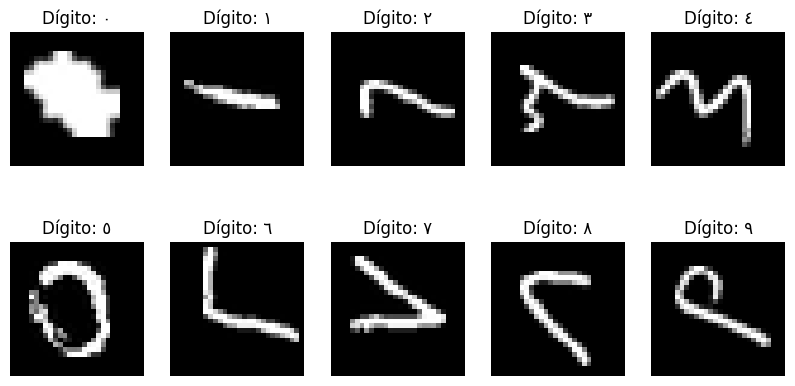

Visualización de dígitos árabes del dataset.


In [17]:
# Mapa de números árabes
# Diccionario que convierte las clases numéricas (0–9) a sus símbolos en dígitos árabes
arabic_digits = {
0:'٠',1:'١',2:'٢',3:'٣',4:'٤',
5:'٥',6:'٦',7:'٧',8:'٨',9:'٩'
}

# Crear una figura con una cuadrícula de 2 filas y 5 columnas para mostrar 10 imágenes
fig, axs = plt.subplots(2,5, figsize=(10,5))

# Recorrer las primeras 10 imágenes del dataset de entrenamiento
for i in range(10):

    # Convertir el vector de 784 pixeles a imagen 28x28
    img = X_train[i].reshape(28,28)

    # Mostrar la imagen en escala de grises
    axs[i//5, i%5].imshow(img, cmap='gray')

    # Colocar como título el dígito árabe correspondiente a la etiqueta
    axs[i//5, i%5].set_title(f"Dígito: {arabic_digits[y_train[i]]}")

    # Quitar los ejes para que solo se vea la imagen
    axs[i//5, i%5].axis("off")

# Mostrar la figura completa con las 10 imágenes
plt.show()

# Mensaje indicando que la visualización se realizó
print("Visualización de dígitos árabes del dataset.")

In [19]:
# Crear Dataset personalizado

# Clase que define cómo PyTorch debe leer los datos
class ArabicDigitsDataset(Dataset):

    # Constructor: recibe los datos X y las etiquetas y
    def __init__(self, X, y):

        # Convertimos los datos a tensores de PyTorch
        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).long()

    # Devuelve el número total de ejemplos del dataset
    def __len__(self):

        return len(self.X)

    # Devuelve un ejemplo específico (imagen y etiqueta)
    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]


# Crear datasets de entrenamiento y prueba
train_dataset = ArabicDigitsDataset(X_train, y_train)
test_dataset = ArabicDigitsDataset(X_test, y_test)


# Crear DataLoaders

# Tamaño de batch
batch_size = 256

# DataLoader de entrenamiento (mezcla los datos)
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

# DataLoader de prueba (no mezcla)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Mensajes informativos
print("Dataset y DataLoader creados correctamente.")
print("Batch size:", batch_size)

Dataset y DataLoader creados correctamente.
Batch size: 256


In [20]:
class MultiClassNN(nn.Module):  # Definimos una clase de red neuronal para clasificación multiclase

    def __init__(self):  # Constructor del modelo (se ejecuta al crear el modelo)

        super().__init__()  # Llama al constructor de la clase padre nn.Module

        self.net = nn.Sequential(  # Creamos la red como una secuencia de capas

            nn.Linear(784,256),   # Capa totalmente conectada: 784 entradas (28x28 píxeles) → 256 neuronas
            nn.ReLU(),            # Función de activación ReLU para introducir no linealidad

            nn.Linear(256,128),   # Segunda capa: 256 → 128 neuronas
            nn.ReLU(),            # Activación ReLU nuevamente

            nn.Linear(128,10)     # Capa de salida: 128 → 10 neuronas (una por cada dígito 0-9)
        )

    def forward(self,x):  # Método que define cómo pasan los datos por la red

        return self.net(x)  # Ejecuta todas las capas definidas en nn.Sequential


model = MultiClassNN().to(device)  # Creamos el modelo y lo enviamos a CPU o GPU según el dispositivo

print("Modelo de red neuronal creado.")  # Mensaje para confirmar que el modelo se creó
print(model)  # Imprime la arquitectura completa de la red neuronal

Modelo de red neuronal creado.
MultiClassNN(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [21]:
criterion = nn.CrossEntropyLoss()
# Definimos la función de pérdida para clasificación multiclase.
# CrossEntropyLoss combina Softmax + LogLoss y compara las predicciones con la clase real.

optimizer = optim.Adam(
    model.parameters(),   # Le pasamos los parámetros (pesos) del modelo que se van a actualizar
    lr=0.001              # Learning rate: qué tan grande será el paso al actualizar los pesos
)

print("Función de pérdida y optimizador configurados.")
# Mensaje para confirmar que el modelo ya tiene su función de pérdida y optimizador listos

Función de pérdida y optimizador configurados.


In [22]:
train_losses = []
# Lista donde se guardará el valor de la función de costo (loss)
# en cada epoch durante el entrenamiento.

train_accuracies = []
# Lista donde se guardará la precisión (accuracy)
# del modelo en cada epoch.

print("Listas de métricas inicializadas.")
# Mensaje para confirmar que las listas para guardar métricas ya están listas

Listas de métricas inicializadas.


In [23]:
epochs = 10
# Número de veces que el modelo recorrerá todo el dataset de entrenamiento

for epoch in range(epochs):
# Bucle principal de entrenamiento (una vuelta completa al dataset por epoch)

    model.train()
    # Ponemos el modelo en modo entrenamiento (activa gradientes)

    total_loss = 0
    correct = 0
    total = 0
    # Variables para acumular métricas del entrenamiento

    for X_batch, y_batch in train_loader:
    # Recorremos el dataset en batches (grupos de datos)

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # Enviamos los datos a CPU o GPU según el dispositivo configurado

        optimizer.zero_grad()
        # Reinicia los gradientes para evitar que se acumulen

        outputs = model(X_batch)
        # Forward pass: la red genera predicciones

        loss = criterion(outputs, y_batch)
        # Calculamos el error entre predicción y valor real

        loss.backward()
        # Backpropagation: calcula los gradientes de cada peso

        optimizer.step()
        # Actualiza los pesos del modelo usando Adam

        total_loss += loss.item()
        # Acumulamos el costo del batch

        preds = torch.argmax(outputs, dim=1)
        # Obtenemos la clase predicha (la de mayor probabilidad)

        correct += (preds == y_batch).sum().item()
        # Contamos cuántas predicciones fueron correctas

        total += y_batch.size(0)
        # Sumamos el número total de ejemplos procesados

    epoch_loss = total_loss / len(train_loader)
    # Promedio del costo en todos los batches del epoch

    epoch_acc = correct / total
    # Precisión total del epoch

    train_losses.append(epoch_loss)
    # Guardamos el costo del epoch en la lista

    train_accuracies.append(epoch_acc)
    # Guardamos la precisión del epoch

    print(f"Epoch {epoch+1}/{epochs}")
    # Mostrar número de epoch actual

    print("Costo:", epoch_loss)
    # Mostrar costo promedio del epoch

    print("Precisión:", epoch_acc*100,"%")
    # Mostrar precisión en porcentaje

Epoch 1/10
Costo: 0.3031009788525865
Precisión: 92.4 %
Epoch 2/10
Costo: 0.09064635101785051
Precisión: 97.595 %
Epoch 3/10
Costo: 0.06317463644007419
Precisión: 98.32666666666667 %
Epoch 4/10
Costo: 0.04667214254868474
Precisión: 98.725 %
Epoch 5/10
Costo: 0.035211097766110235
Precisión: 99.06166666666667 %
Epoch 6/10
Costo: 0.026931225195368554
Precisión: 99.235 %
Epoch 7/10
Costo: 0.020462819547491504
Precisión: 99.44 %
Epoch 8/10
Costo: 0.016704588656888363
Precisión: 99.53666666666666 %
Epoch 9/10
Costo: 0.013918168947813992
Precisión: 99.59 %
Epoch 10/10
Costo: 0.010808672794101245
Precisión: 99.70333333333333 %


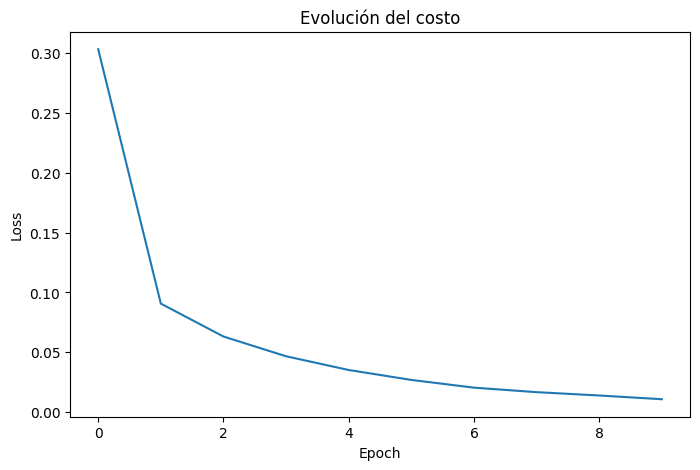

Gráfica de función de costo generada.


In [24]:

# 12. GRÁFICA DE COSTO

plt.figure(figsize=(8,5))
# Creamos una nueva figura para el gráfico y definimos su tamaño

plt.plot(train_losses)
# Graficamos los valores de la función de costo guardados en cada epoch

plt.title("Evolución del costo")
# Título del gráfico

plt.xlabel("Epoch")
# Etiqueta del eje X → número de iteraciones completas del entrenamiento

plt.ylabel("Loss")
# Etiqueta del eje Y → valor de la función de costo

plt.show()
# Mostrar el gráfico en pantalla

print("Gráfica de función de costo generada.")
# Mensaje para confirmar que la gráfica se generó correctamente

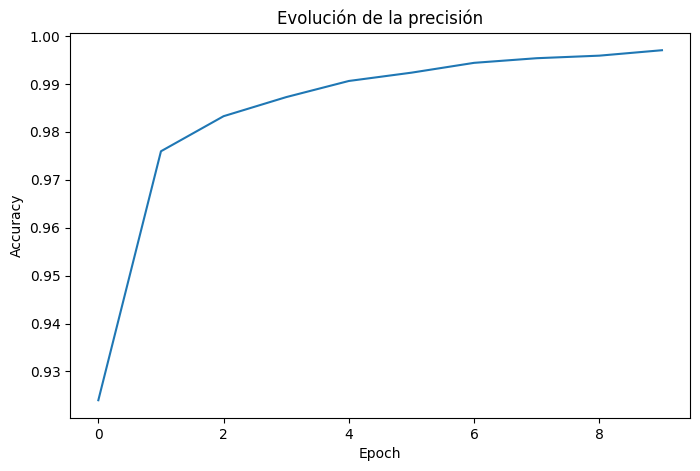

Gráfica de precisión generada.
Precisión final entrenamiento: 99.70333333333333 %


In [25]:
# 13. GRÁFICA DE PRECISIÓN

plt.figure(figsize=(8,5))
# Creamos una nueva figura para mostrar el gráfico de precisión

plt.plot(train_accuracies)
# Graficamos la lista donde guardamos la precisión de cada epoch

plt.title("Evolución de la precisión")
# Título del gráfico

plt.xlabel("Epoch")
# Eje X: número de epochs (veces que el modelo recorrió todo el dataset)

plt.ylabel("Accuracy")
# Eje Y: precisión del modelo (qué tan bien está clasificando)

plt.show()
# Mostrar el gráfico en pantalla

print("Gráfica de precisión generada.")
# Confirmación de que la gráfica se generó correctamente

print("Precisión final entrenamiento:", train_accuracies[-1]*100,"%")
# Muestra la última precisión registrada (la del último epoch) en porcentaje

In [26]:
model.eval()
# Cambia el modelo a modo evaluación (desactiva comportamiento de entrenamiento)

correct = 0
total = 0
# Variables para contar predicciones correctas y total de ejemplos

with torch.no_grad():
# Desactiva el cálculo de gradientes (más rápido y usa menos memoria)

    for X_batch, y_batch in test_loader:
    # Recorremos el dataset de prueba en batches

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        # Enviamos los datos al dispositivo (CPU o GPU)

        outputs = model(X_batch)
        # Forward pass: el modelo genera predicciones

        preds = torch.argmax(outputs, dim=1)
        # Tomamos la clase con mayor probabilidad como predicción final

        correct += (preds == y_batch).sum().item()
        # Sumamos cuántas predicciones fueron correctas

        total += y_batch.size(0)
        # Sumamos el total de ejemplos evaluados

test_accuracy = correct / total
# Calculamos la precisión final del modelo en el dataset de prueba

print("Evaluación en dataset de prueba completada.")
# Mensaje indicando que terminó la evaluación

print("Precisión en TEST:", test_accuracy * 100, "%")
# Mostramos la precisión del modelo en porcentaje

Evaluación en dataset de prueba completada.
Precisión en TEST: 98.17 %


In [27]:
#bueno este solo se guarda en un archivo temporal de colab
PATH = "./checkpoint_multiclase.pt"
# Definimos la ruta y nombre del archivo donde se guardará el modelo

torch.save(model.state_dict(), PATH)
# Guardamos los pesos del modelo (state_dict) en el archivo indicado

print("Checkpoint del modelo guardado en:")
# Mensaje para indicar que el modelo fue guardado

print(PATH)
# Muestra la ruta del archivo donde se guardó el checkpoint
'''
drive.mount('/content/drive')
puedes guardar el modelo así:

PATH = "/content/drive/MyDrive/checkpoint_multiclase.pt"
torch.save(model.state_dict(), PATH)
print("Modelo guardado en Drive:", PATH)

Entonces el archivo aparecerá en:
Mi unidad (MyDrive)
   checkpoint_multiclase.pt

Para qué sirve después
Luego puedes cargar el modelo sin volver a entrenar:

model.load_state_dict(torch.load(PATH))
model.eval()
'''

Checkpoint del modelo guardado en:
./checkpoint_multiclase.pt


'\ndrive.mount(\'/content/drive\')\npuedes guardar el modelo así:\n\nPATH = "/content/drive/MyDrive/checkpoint_multiclase.pt"\ntorch.save(model.state_dict(), PATH)\nprint("Modelo guardado en Drive:", PATH)\n\nEntonces el archivo aparecerá en:\nMi unidad (MyDrive)\n   checkpoint_multiclase.pt\n\nPara qué sirve después\nLuego puedes cargar el modelo sin volver a entrenar:\n\nmodel.load_state_dict(torch.load(PATH))\nmodel.eval()\n'

In [28]:
model_loaded = MultiClassNN().to(device)
# Creamos una nueva instancia del modelo con la misma arquitectura
# y lo enviamos al dispositivo (CPU o GPU)

model_loaded.load_state_dict(torch.load(PATH))
# Cargamos los pesos guardados en el archivo checkpoint (.pt)
# dentro del modelo recién creado

model_loaded.eval()
# Cambiamos el modelo a modo evaluación (no entrenamiento)

print("Modelo cargado correctamente desde checkpoint.")
# Mensaje para confirmar que el modelo se cargó correctamente

Modelo cargado correctamente desde checkpoint.


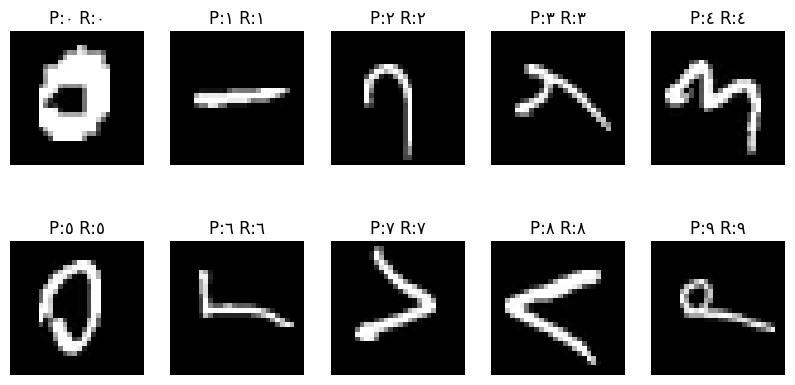

Visualización de predicciones completada.


In [29]:
fig, axs = plt.subplots(2,5, figsize=(10,5))
# Creamos una figura con una cuadrícula de 2 filas y 5 columnas para mostrar 10 imágenes

model_loaded.eval()
# Ponemos el modelo en modo evaluación

for i in range(10):
# Bucle para mostrar las primeras 10 imágenes del dataset de prueba

    img = torch.tensor(X_test[i]).float().to(device)
    # Convertimos la imagen i del dataset a tensor de PyTorch
    # y la enviamos al dispositivo (CPU o GPU)

    output = model_loaded(img)
    # Pasamos la imagen por la red neuronal para obtener las predicciones

    pred = torch.argmax(output).item()
    # Tomamos la clase con mayor probabilidad como predicción del modelo

    real = y_test[i]
    # Obtenemos la etiqueta real de la imagen

    axs[i//5, i%5].imshow(X_test[i].reshape(28,28), cmap='gray')
    # Mostramos la imagen (784 → 28x28 píxeles)

    axs[i//5, i%5].set_title(
        f"P:{arabic_digits[pred]} R:{arabic_digits[real]}"
    )
    # Título de la imagen:
    # P = predicción del modelo
    # R = valor real

    axs[i//5, i%5].axis("off")
    # Quitamos los ejes para que solo se vea la imagen

plt.show()
# Mostramos la figura completa con las 10 imágenes

print("Visualización de predicciones completada.")
# Mensaje indicando que la visualización terminó

In [30]:
index = 25
# Elegimos una imagen específica del dataset de prueba (posición 25)

img = torch.tensor(X_test[index]).float().to(device)
# Convertimos esa imagen a tensor de PyTorch y la enviamos al dispositivo (CPU o GPU)

output = model_loaded(img)
# Pasamos la imagen por el modelo para obtener las probabilidades de cada clase

pred = torch.argmax(output).item()
# Tomamos la clase con mayor probabilidad como predicción del modelo

print("Ejemplo seleccionado:", index)
# Mostramos el índice de la imagen utilizada

print("Dígito real:", arabic_digits[y_test[index]])
# Mostramos el dígito real usando el mapa de números árabes

print("Predicción del modelo:", arabic_digits[pred])
# Mostramos el dígito que el modelo predijo

Ejemplo seleccionado: 25
Dígito real: ٥
Predicción del modelo: ٥


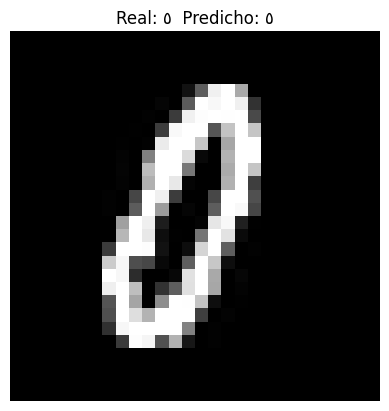

Imagen mostrada correctamente.


In [31]:
plt.imshow(X_test[index].reshape(28,28), cmap='gray')
# Mostramos la imagen seleccionada convirtiendo el vector (784) en una matriz 28x28

plt.title(
    f"Real: {arabic_digits[y_test[index]]}  Predicho: {arabic_digits[pred]}"
)
# Título de la imagen mostrando:
# el número real y el número predicho por el modelo (en dígitos árabes)

plt.axis("off")
# Oculta los ejes del gráfico para que solo se vea la imagen

plt.show()
# Muestra la imagen en pantalla

print("Imagen mostrada correctamente.")
# Mensaje para confirmar que la imagen se visualizó correctamente

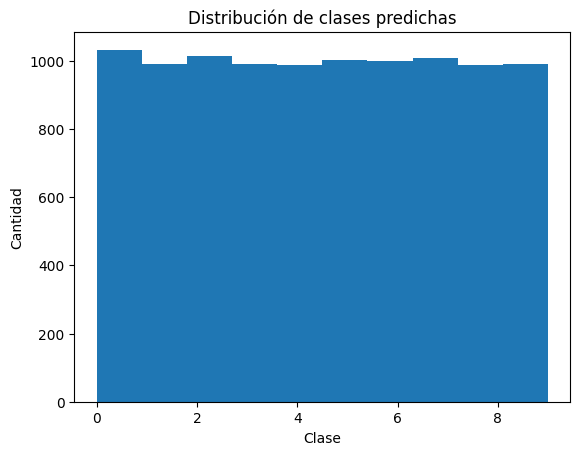

Distribución de predicciones generada.


In [32]:
all_preds = []
# Lista donde guardaremos todas las clases predichas por el modelo

model_loaded.eval()
# Ponemos el modelo en modo evaluación

with torch.no_grad():
# Desactivamos el cálculo de gradientes para ahorrar memoria y acelerar la evaluación

    for X_batch, y_batch in test_loader:
    # Recorremos el dataset de prueba en batches

        X_batch = X_batch.to(device)
        # Enviamos los datos al dispositivo (CPU o GPU)

        outputs = model_loaded(X_batch)
        # Pasamos el batch por el modelo para obtener las predicciones

        preds = torch.argmax(outputs, dim=1)
        # Elegimos la clase con mayor probabilidad para cada ejemplo del batch

        all_preds.extend(preds.cpu().numpy())
        # Convertimos las predicciones a NumPy y las agregamos a la lista global

plt.hist(all_preds, bins=10)
# Creamos un histograma con la cantidad de predicciones por clase (0-9)

plt.title("Distribución de clases predichas")
# Título del gráfico

plt.xlabel("Clase")
# Eje X → clases predichas

plt.ylabel("Cantidad")
# Eje Y → número de veces que se predijo cada clase

plt.show()
# Mostramos el gráfico

print("Distribución de predicciones generada.")
# Mensaje indicando que el gráfico se creó correctamente

In [33]:
torch.save(model_loaded, "modelo_multiclase_completo.pt")
# Guarda el modelo completo (arquitectura + pesos) en un archivo .pt
# A diferencia de state_dict(), aquí se guarda todo el modelo listo para cargar directamente

print("Modelo completo guardado correctamente.")
# Mensaje para confirmar que el modelo se guardó sin problemas

Modelo completo guardado correctamente.


In [34]:
modelo_final = torch.load("modelo_multiclase_completo.pt", weights_only=False)
# Cargamos el modelo completo desde el archivo .pt guardado anteriormente
# weights_only=False indica que queremos cargar toda la estructura del modelo

modelo_final.eval()
# Cambiamos el modelo a modo evaluación (desactiva comportamiento de entrenamiento)

print("Modelo completo cargado correctamente.")
# Mensaje para confirmar que el modelo fue cargado exitosamente

Modelo completo cargado correctamente.


In [35]:
print("RESULTADO FINAL DEL MODELO")
# Mensaje principal para mostrar el resumen del rendimiento del modelo

print("Precisión entrenamiento final:")
# Indicamos que mostraremos la precisión obtenida al final del entrenamiento

print(train_accuracies[-1] * 100, "%")
# Mostramos la última precisión registrada durante el entrenamiento
# train_accuracies[-1] significa el último valor de la lista

print()
# Línea en blanco para separar visualmente los resultados

print("Precisión en dataset de prueba:")
# Indicamos que ahora mostraremos la precisión en datos que el modelo no vio durante entrenamiento

print(test_accuracy * 100, "%")
# Mostramos la precisión final del modelo en el dataset de prueba

RESULTADO FINAL DEL MODELO
Precisión entrenamiento final:
99.70333333333333 %

Precisión en dataset de prueba:
98.17 %


In [190]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# Ruta de la imagen
img_path = '/content/drive/MyDrive/colab/lab5/imagen.png'

# Abrir imagen
img = Image.open(img_path)

# Convertir a escala de grises
img = img.convert('L')

# Redimensionar al tamaño del dataset
img = img.resize((28,28))

# Convertir a numpy
img_arr = np.array(img)

print("Imagen cargada correctamente.")

Imagen cargada correctamente.


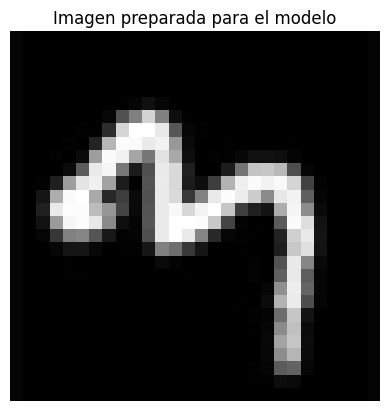

Imagen invertida y normalizada correctamente.


In [191]:
# Invertir colores porque el dataset usa fondo negro
# img_arr = 255 - img_arr

# Normalizar
img_arr = img_arr / 255.0

plt.imshow(img_arr, cmap='gray')
plt.title("Imagen preparada para el modelo")
plt.axis("off")
plt.show()

print("Imagen invertida y normalizada correctamente.")

In [192]:
# Convertir a vector de 784
img_vec = img_arr.reshape(1,784)

# Convertir a tensor
img_tensor = torch.tensor(img_vec).float().to(device)

print("Imagen convertida a tensor.")
print("Shape:", img_tensor.shape)

Imagen convertida a tensor.
Shape: torch.Size([1, 784])


In [193]:
model_loaded.eval()

with torch.no_grad():

    output = model_loaded(img_tensor)

    pred = torch.argmax(output, dim=1).item()
print("PREDICCIÓN DE imagen.png")
print("Clase predicha:", pred)
print("Dígito árabe:", arabic_digits[pred])

PREDICCIÓN DE imagen.png
Clase predicha: 4
Dígito árabe: ٤


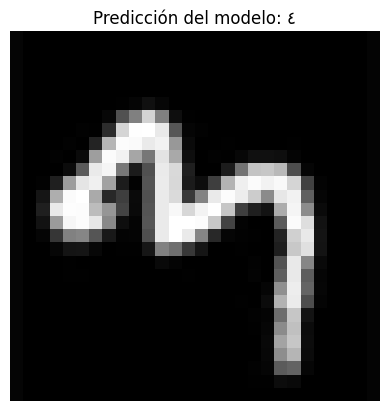

Predicción visual mostrada.


In [194]:
plt.imshow(img_arr, cmap='gray')

plt.title(f"Predicción del modelo: {arabic_digits[pred]}")

plt.axis("off")

plt.show()

print("Predicción visual mostrada.")